[动态规划](./basic_algorithm/dp.md)  


动态规划就是把大问题变成小问题，并解决了小问题重复计算的方法称为动态规划  

动态规划和 DFS 区别
- 二叉树 子问题是没有交集，所以大部分二叉树都用递归或者分治法，即 DFS，就可以解决
- 像 triangle 这种是有重复走的情况，子问题是有交集，所以可以用动态规划来解决


动态规划是一种“从底至顶”的方法：从最小子问题的解开始，迭代地构建更大子问题的解，直至得到原问题的解。

In [ ]:
triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
def minimumTotal(triangle):
    # dp 表
    dp = []
    # 初始状态
    row = col = 0
    dp.append((row,col))
    # 状态转移方程
    for row in range(1,len(triangle)):
        col = col if triangle[row][col] < triangle[row][col+1] else col+1
        dp.append((row,col))
    print(dp)
    # post precessing
    res = 0
    for row,col in dp:
        res += triangle[row][col]
    return res
triangle = [[-1],[2,3],[1,-1,-3]]
# 答案是-1=-1+3-3。没把累积和考虑进去，用的是贪心局部最优
minimumTotal(triangle)

# cuo

In [ ]:
# 很多dp 题可以优化空间使用

In [ ]:
triangle = [[-1],[2,3],[1,-1,-3]]
for row in triangle[1:]:
    print(row[0])
    break
-1 + 2

dp[i][j] = min(dp[i+1][j], dp[i+1][j+1]) + triangle[i][j]  
上面这个状态转移方程是自底向上的，初始解是triangle[-1],从第二个解开始算
- dp[i][j] ： 这里的i指的是状态，从0开始，状态0的解是dp[0][j], 因为解是一个数组，所以用这个表述
- 根据题意在计算dp[1] 的解数组的时候，转态1对应的解数组中0号元素应该为当前值+初始解的min([0],[1])
- 这就是状态转移矩阵，多看多练，动态规划比较灵活

In [ ]:
[1,2] + 1

In [ ]:
# dp[i][j] = triangle[i] + min(dp[i])
# 注意点：两边有上面的得到，中间的要求和最小值
# - min(dp[row-1][i],dp[row-1][i-1])
def minimumTotal(triangle):
    # dp 表
    dp = triangle
    # 初始状态
    for row in range(1,len(triangle)):
        dp[row][0] += dp[row-1][0]
        dp[row][-1] += dp[row-1][-1]
        for col in range(1,len(dp[row])-1):
            dp[row][col] += min(dp[row-1][col-1],dp[row-1][col])
    print(dp)  
    return min(dp[-1])
triangle = [[-1],[2,3],[1,-1,-3]]
# triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
minimumTotal(triangle)

In [ ]:

def minimumTotal(triangle):
    # dp 表
    dp = triangle[-1].copy()
    print(dp)
    for i in range(-2,-len(triangle)-1,-1):
        for j in range(len(triangle[i])):
            dp[j] = triangle[i][j] + min(dp[j],dp[j+1])
    print(dp)
        
    return dp[0]
# triangle = [[-1],[2,3],[1,-1,-3]]
triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
# 答案是-1=-1+3-3。没把累积和考虑进去，用的是贪心局部最优
minimumTotal(triangle)

### 常见四种类型 （有四种常见的DP模版）
- 1、Matrix DP (10%)
- 2、Sequence (40%)
- 3、Two Sequences DP (40%)
- 4、Backpack (10%)
> note:
> - 贪心算法大多题目靠背答案，所以如果能用动态规划就尽量用动规，不用贪心算法


1、Matrix DP (10%) ，在这种题中，dp表初始化为何矩阵大小一样就好了，在逐步求解的过程中，就是通过就局部min逐渐减少可能得路径，等走到终点，唯一的最小路径和也出来了，triangle也属于矩阵 DP
- 做题技巧：行扫描，dp表的大小是矩阵的列数 dp = [0]*len(matrix[0])

In [ ]:
[1,3,1]

In [ ]:
def minPathSum(grid):
    M,N = len(grid),len(grid[0])
    # dp 表
    dp = grid
    # 初始状态
    # 初始状态dp[0][0] 就是出发点，初始化表的时候，已经记下来了，初始化边界,前缀和
    for i in range(1,M):
        dp[i][0] += dp[i-1][0]
    for j in range(1,N):
        dp[0][j] += dp[0][j-1]

    # 状态转移
    
    for i in range(1,M):
        for j in range(1,N):
            dp[i][j] += min(dp[i-1][j], dp[i][j-1])
    print(dp)
    return dp[-1][-1]
    
grid = [[1,3,1],[1,5,1],[4,2,1]]
minPathSum(grid)

### 空间优化效果
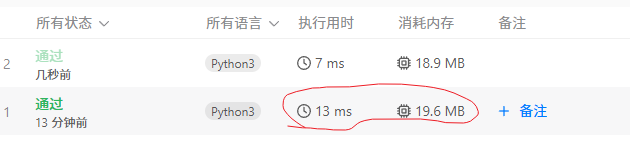 

甚至还加快了速度！

In [ ]:
# 优化一下最小路径和，空间优化
# 这里空间优化很好理解，只保留行大小，每次刷新行就好了
def minPathSum(grid):
    M,N = len(grid),len(grid[0])
    # dp 表
    dp = grid[0]
    # 初始状态
    # 初始状态dp[0][0] 就是出发点，初始化表的时候，已经记下来了，初始化边界,前缀和
    for j in range(1,N):
        dp[j] += dp[j-1]

    # 状态转移
    for i in range(1,M):
        dp[0] +=  grid[i][0]
        for j in range(1,N):
            dp[j] = grid[i][j] + min(dp[j], dp[j-1])
    print(dp)
    return dp[-1]
grid = [[1,3,1],[1,5,1],[4,2,1]]
minPathSum(grid)

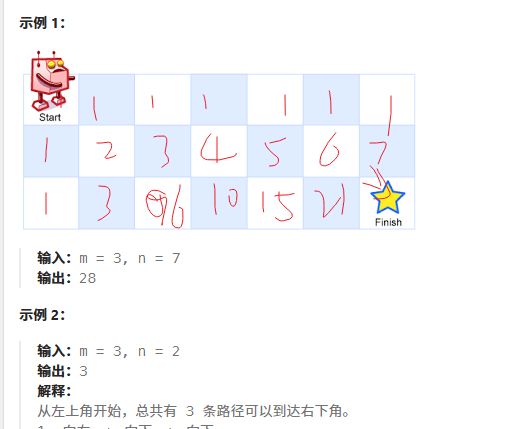

In [ ]:
def uniquePath(m,n):
    dp = [1]*n
    for _ in range(1,m):
        for i in range(1,n):
            dp[i] += dp[i-1]
    print(dp)
    return dp[-1]
uniquePath(3,3)

> 预见障碍怎么办，该点变为0    


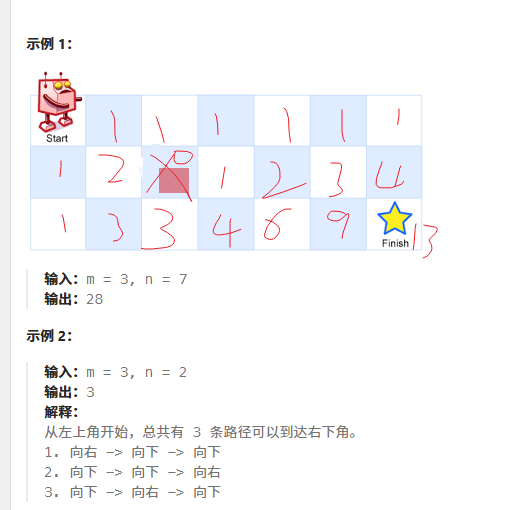  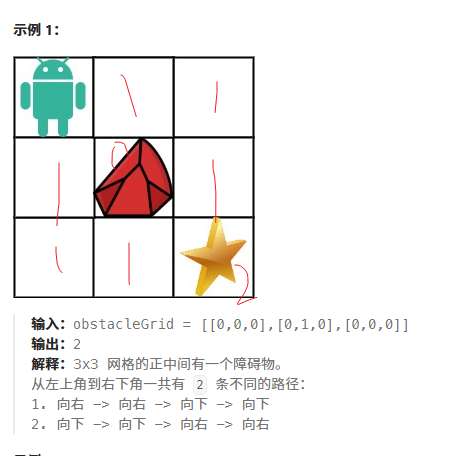  

有坑：障碍也可以出现在起始点

In [ ]:
def uniquePathsWithObstacles(obstacleGrid):
    if obstacleGrid[0][0]:
        return 0
    m,n = len(obstacleGrid),len(obstacleGrid[0])
    # dp 表
    dp = [1]*n
    # 状态初始化
    for j in range(1,n):
        if obstacleGrid[0][j]:
            break
    else:
        j = -1   # 循环没遇到 break（说明没找到,Python 独有）
    if j != -1:
        dp[j:] = [0]*(n-j)
    # 状态转移
    for i in range(1,m):
        if obstacleGrid[i][0]:
            dp[0] = 0
        for j in range(1,n):
            if obstacleGrid[i][j]:
                dp[j] = 0
            else :
                dp[j] += dp[j-1]

    print(dp)
    return dp[-1]
obstacleGrid = [[0,0,0],[0,1,0],[0,0,0]]
uniquePathsWithObstacles(obstacleGrid)

### 2、序列类型（40%） 代表是爬楼梯


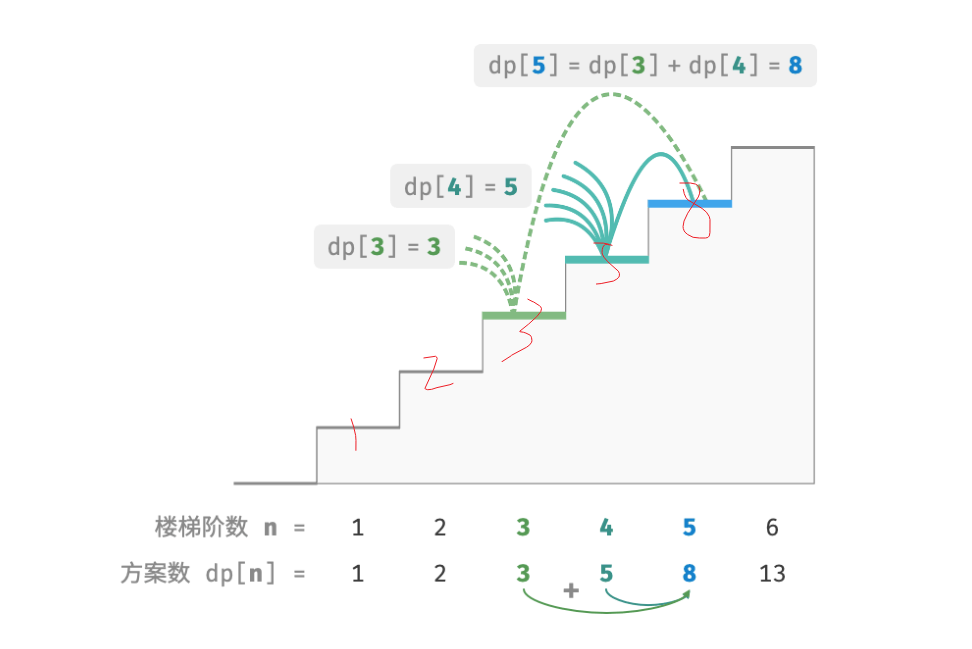

可以看到从第三层楼梯开始，第三层楼梯可以有1和个2层来，那么就是他们的方案数相加，这个矩阵问题有点类似，当前解的来源，子解集的大小，那么当爬楼梯的人，从1,2步，变为了1,2,3步, 这种问题也好解决了
序列问题，内存特别省，简单问题一恶搞标量就够了

In [ ]:
def climbStairs(n):
    if n in [1,2]:
        return n
    dp = [1,2]
    for i in range(2,n,2):
        dp[0] = dp[0] + dp[1]
        dp[1] = dp[0] + dp[1]
        print(dp)
    return dp[(n+1) % 2]
climbStairs(4)

In [ ]:
curr_max = 5
y = 8
# 1
if curr_max-1 < y:
    curr_max= y
else:
    curr_max = curr_max-1
# 2
curr_max= y if curr_max-1 < y  else curr_max-1

# 3
curr_max = max(curr_max-1,y)

# 结论：python内置的max(),底层是c语言实现的，所以无论从效率还是可读性，max() 可以放心用

8

In [29]:
nums = [9,4,5,5,7,9]
idx, val = max(enumerate(nums), key=lambda x: (x[1], x[0]))
idx, val 

(5, 9)

In [ ]:
# 思路：问题分解后，能否到达最后一个变成了能否到达i-1个，进而编程，i,i-1,i-2,3,2,1
# 从head 到 tail
def canJump(nums):
    # dp表每个状态对应的解，这里max_pos,不是，所以叫做间接DP
    max_pos = nums[0]
    for i in range(1,len(nums)):
        if max_pos < 1:
            return False
        max_pos = max(max_pos-1,nums[i])
    return True

# 加约束：最小跳跃次数
# 思路：我们现在从到达每个位置需要的最小跳跃次数 转换为 当前跳跃次数可以到达的最远距离。
def jump(nums):
    # 贪心比较好
    cur_max = 0
    step_max = 0
    step = 0

    for i in range(len(nums)):
        if cur_max < i:
            return float('inf')
        if step_max < i:  # can't reach i in current number of steps
            step += 1
            step_max = cur_max
        cur_max = max(cur_max, i + nums[i]) # DP
        print(step)
    return step

    
nums = [2,3,1,1,4]
# nums = [2,3,1]
# canJump(nums)
jump(nums)


0
1
1
2
2


2

In [ ]:
# palindrome
def minCut(s):
    N = len(s)
    # 目标DP
    dp_min = [0] * N
    # 回文DP
    dp_pal = [True] * N
    def ifPalindrome(i,j):
        # 回文DP 设计的真好
        dp_pal[i] = (s[i] == s[j] and dp_pal[i+1])
        return dp_pal[i]
    for j in range(1,N):
        min_cut = dp_min[j-1] + 1
        if ifPalindrome(0, j):
            min_cut = 0
        for i in range(1, j):
            if ifPalindrome(i, j):
                min_cut = min(min_cut, dp_min[i - 1] + 1)
        
        dp_min[j] = min_cut
                
    
    return dp_min[-1]
s= "aab"
minCut(s)

1

bisect.bisect_left(nums, x)  
在已排序的列表 nums 中，找到值 x 应该插入的位置（保持排序）。
- 如果 x 已经存在，返回它 最左边 的下标；
- 如果 x 不存在，返回它应该插入的位置下标；
- 不会修改原列表，只返回下标。

In [46]:
import bisect
def lengthOfLIS(nums):
    seq = [nums[0]]
    for i in range(1, len(nums)):
        idx = bisect.bisect_left(seq, nums[i])
        if idx == len(seq):  # 插入位置不是最后一个，说明
            seq.append(nums[i])
        else:
            seq[idx] = nums[i]

    print(seq)
    return len(seq)
    
nums = [10,9,2,5,3,7,101,18]
lengthOfLIS(nums)

[2, 3, 7, 18]


4